**Phasic** is a library for modelling and inference on Markov jump processes, which move through multiple states on the the way to a final (absorbing) state. Using algorithms that translate existing matrix-based results for phase-type distributions into a graph framework, Phasic efficiently computes exact moments and distributions of waiting times.

## Installing

Phasic is most easily installed using either Pixi, Conda or Pip:

::: {.panel-tabset}

## Pixi

```bash
pixi workspace channel add munch-group
pixi install phasic
```

## Conda

```bash
conda install -c munch-group -c conda-forge phasic
```

## Pip

```bash
pip install phasic
```

:::

## Your First Model

The simplest possible model has a single state in where it stays with  process—you start, wait some random amount of time, then finish. Each states is represented by a vector (list/array) of integers each representing a state property. In this simple case, we only need a single integer.

The easiest way to create that (and any other model) is to write a "callback" function. Think of the function as providing the answer to this question: "Assuming some state in your Markov process, what other states can the process jump to and with what rates?". When passed a state vector, it must return a (possibly empty) list of child states that the process can jump to, paired with the rates at which these occur.

If you can think about your favorite Markov model in this way, phasic will do the rest for you.

In [1]:
#| echo: false
from phasic import Graph
import numpy as np
from vscodenb import set_vscode_theme
set_vscode_theme()
%config InlineBackend.figure_format = 'svg'

In [1]:
from phasic import Graph
import numpy as np

def model(state):
    transitions = []               # List for transitions from state
    if state[0] < 2:               # Control transitions allowed
        child = state.copy()       # Make a copy to modify
        child[0] += 1              # Make the child state
        trans = [child, 2.0]       # Pair the child with a transition rate (in a list not tuple)
        transitions.append(trans)  # Append transition 
    return transitions

You can now create the graph by passing the callback function to the `Graph` constructor, along the `ipv` keyword argument specifying in which state the process begins. Then plot the graph to make sure your callback function works as expected:

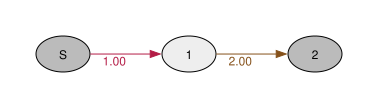

In [2]:
graph = Graph(model, ipv=[1])
graph.plot()

This models an exponential distribution with rate 2.0. Once we've constructed the graph, we can compute moments directly. The expected waiting time is 1/rate = 0.5, which we verify by calling `expectation()` on the graph:

In [3]:
graph.expectation(), graph.variance()

(0.5, 0.25)

In [4]:
graph.moments(10)

[0.5, 0.5, 0.75, 1.5, 3.75, 11.25, 39.375, 157.5, 708.75, 3543.75]

You can compute probability distributions. The `pdf()` method returns the probability density at a given time, while `cdf()` returns the probability that the waiting time is less than or equal to that time:


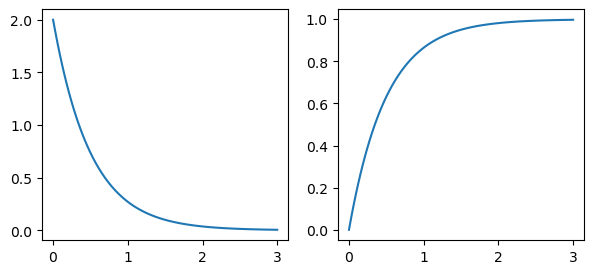

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
vals = np.linspace(0, 3, 100)
axes[0].plot(vals, graph.pdf(vals))
axes[1].plot(vals, graph.cdf(vals))
plt.show()

You can also draw random samples from the distribution:

In [6]:
samples = graph.sample(10000)
samples[:10]

array([0.58395702, 0.07442261, 0.5799632 , 0.18468094, 0.34035889,
       0.63714367, 0.43480335, 0.02143758, 0.11801597, 0.0095593 ])

Sample mean vs. expectation:

In [7]:
np.mean(samples).item(), graph.expectation()

(0.49919273294182787, 0.5)

Using rewards, you can compute expectations and PDFs of marginal waiting times, time spent in each state and much more - all as easily as for this simple example. You an learn more about this, as well as about Bayesian inference in the tutorials. For now, just appreciate how easily complex models can be constructed:

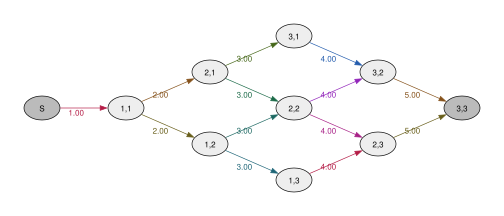

In [8]:
from phasic import Graph
import numpy as np

def mesh(state, max_val=None):
    transitions = []
    for i in range(state.size):
        if state[i] <= max_val:
            child = state.copy()
            child[i] += 1
            trans = [child, state.sum()]
            transitions.append(trans)
    return transitions

graph = Graph(mesh, ipv=[1, 1], max_val=2)
graph.plot()

Note how any keyword arguments are passed onto the callback function:

1.3225441834186733


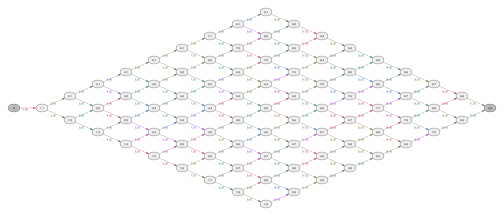

In [9]:
graph = Graph(mesh, ipv=[1, 1], max_val=8)
print(graph.expectation())
graph.plot()